## Modify this section  

In [ ]:
from functions_EMG_FINAL_AE_OM import *    # modify the .py file name

file_number = 2 # modify the file number

EMG_file = f"train{file_number}_data.csv" #training dataset
EMG2_file = f"test{file_number}_data.csv" #testing dataset
label_file = f"train{file_number}_labels.csv"
label2_file = f"test{file_number}_labels.csv"

# You can skip this cell (or you may run it, just need to change the data_path :))

In [10]:
all_scores, mean_score, all_confusions, mean_conf_matrix = evaluate_all_pairs(window_size=50, swap_train_test=False, data_path="./")

Generated labels: [0 0 0 1 1 1 1 1 1 0 0 0 0 2 2 2 2 2 2 2 2 2 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 2 2 2 2 2 2 2 2 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 0 0
 0 0 0 0 0 0 2 2 2 2 2 2 2 2 0 0 0 0 0 2 2 2 2 2 2 0]
Training accuracy: 90.00%
train1_data.csv -> test1_data.csv
Mean class accuracy: 0.801587
Confusion Matrix:
[[0.91666667 0.08333333 0.        ]
 [0.17857143 0.82142857 0.        ]
 [0.33333333 0.         0.66666667]]

Generated labels: [0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 2 2 2 2 2 2 0 0 0 0 0 0 0 1 1 1 1
 1 1 0 0 0 0 0 0 0 0 2 2 2 2 2 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1
 0 0 0 0 0 0 0 0 2 2 2 2 2 0 0 0 0 0 2 2 2 2 2 0 0 0]
Training accuracy: 88.00%
train2_data.csv -> test2_data.csv
Mean class accuracy: 0.855757
Confusion Matrix:
[[0.96923077 0.         0.03076923]
 [0.23529412 0.76470588 0.        ]
 [0.16666667 0.         0.83333333]]

Generated labels: [0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 2 2 2 2 2 2 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0
 0 0 0 2 2 2 2 2 2 0 0 0 0 

## Do not modify this section

### Test 1 

debut acquisition
frequence acquisition : 505106.58 sps


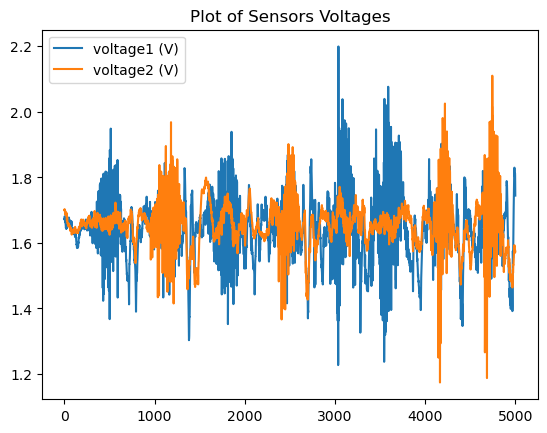

Generated labels: [0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 2 2 2 2 2 2 0 0 0 0 0 0 0 1 1 1 1
 1 1 0 0 0 0 0 0 0 0 2 2 2 2 2 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1
 0 0 0 0 0 0 0 0 2 2 2 2 2 0 0 0 0 0 2 2 2 2 2 0 0 0]
Training accuracy: 88.00%
Démarrage classification temps réel...
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0

In [11]:
@dataclass
class OfflineStream:

    def __init__(self, data):
        self.data = data            # array of emg data read from csv file
        self.pointer = 0            # pointer to the current emg data in the array

    @property
    def voltage(self):
        if self.pointer < len(self.data):
            value = self.data[self.pointer]
            self.pointer += 1
        else:
            value = 0.0
        return value


@dataclass
class OutputSim:

    def __init__(self):
        self.logs = [0]

    def ChangeFrequency(self, freq):
        if freq == 325:
            self.logs.append(1)
        else:
            self.logs.append(2)

    def ChangeDutyCycle(self, freq):
        if freq == 30:
            self.logs.append(1)
        else:
            self.logs.append(2)

    def start(self, value):
        pass

    def stop(self):
        self.logs.append(0)

Y = pd.read_csv(label_file)

chan1 = OfflineStream(pd.read_csv(EMG_file).values[:, 0])       # chan 1 emulator
chan2 = OfflineStream(pd.read_csv(EMG_file).values[:, 1])       # chan 2 emulator
chan3 = OfflineStream(pd.read_csv(EMG2_file).values[:, 0])       # chan 1 emulator
chan4 = OfflineStream(pd.read_csv(EMG2_file).values[:, 1])       # chan 2 emulator
buzzer = OutputSim()                                            # buzzer emulator

# general parameters
window_size = 50                                                # evaluation window length (samples)
number_window_training = 100                                     # number of windows to sample for training data set
number_window_testing = 100                                      # number of windows to sample for offline testing

training_file_name = create_new_sampling_file("data/", "training_acquisition")
acquire_training_dataset(chan1, chan2, window_size, number_window_training, training_file_name)

# visual validation of data acquisition
visualize_sampling(training_file_name)

# classifier training (offline training)
classifier = train_classifier(training_file_name, window_size)

# buzzer control (online test)
testing_file_name = create_new_sampling_file("data/", "testing_acquisition")
final_labels = test_classifier(classifier, chan3, chan4, window_size, number_window_testing,buzzer, testing_file_name)

print(final_labels)

del chan1
del chan2
del buzzer


Mean class accuracy: 0.8568459862577509
Confusion Matrix:
 [[0.96923077 0.         0.03076923]
 [0.17647059 0.82352941 0.        ]
 [0.16666667 0.05555556 0.77777778]]


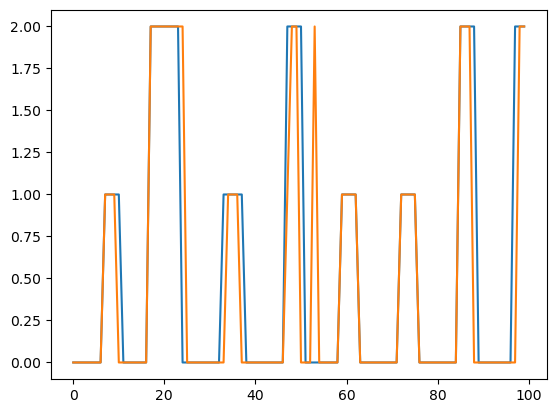

In [12]:
# Performance analysis

LT = pd.read_csv(label2_file)
labels = LT['Downsampled Carrier']

switched_labels=final_labels

from sklearn.metrics import confusion_matrix, balanced_accuracy_score

# Calculate the mean class accuracy
mean_class_accuracy1 = balanced_accuracy_score(labels, switched_labels)

# Create the confusion matrix
conf_matrix1 = confusion_matrix(labels, switched_labels, normalize='true')

print("Mean class accuracy:", mean_class_accuracy1)
print("Confusion Matrix:\n", conf_matrix1)

plt.plot(labels)
plt.plot(switched_labels)

### Test 2 

In [13]:
file_number = 6 # modify the file number
EMG_file = f"test{file_number}_data.csv"
EMG2_file = f"train{file_number}_data.csv"
label_file = f"test{file_number}_labels.csv"
label2_file = f"train{file_number}_labels.csv"

debut acquisition
frequence acquisition : 544955.43 sps


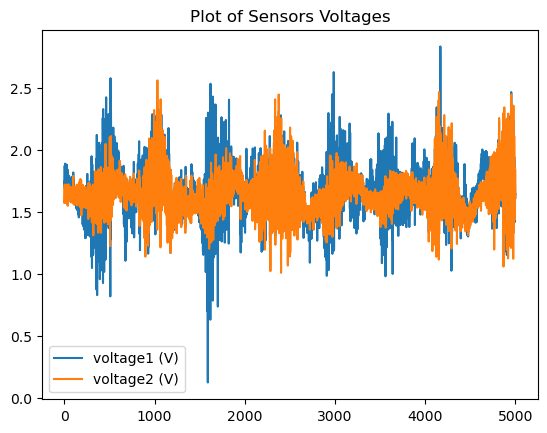

Generated labels: [0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 2 2 2 2 2 2 2 2 0 0 0 0 0 0 1 1 1 1 1 0
 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1
 1 0 0 0 0 0 0 2 2 2 2 2 2 0 0 0 0 0 0 0 0 2 2 2 2 2]
Training accuracy: 88.00%
Démarrage classification temps réel...
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1

In [14]:
@dataclass
class OfflineStream:

    def __init__(self, data):
        self.data = data            # array of emg data read from csv file
        self.pointer = 0            # pointer to the current emg data in the array

    @property
    def voltage(self):
        if self.pointer < len(self.data):
            value = self.data[self.pointer]
            self.pointer += 1
        else:
            value = 0.0
        return value


@dataclass
class OutputSim:

    def __init__(self):
        self.logs = [0]

    def ChangeFrequency(self, freq):
        if freq == 325:
            self.logs.append(1)
        else:
            self.logs.append(2)

    def ChangeDutyCycle(self, freq):
        if freq == 30:
            self.logs.append(1)
        else:
            self.logs.append(2)

    def start(self, value):
        pass

    def stop(self):
        self.logs.append(0)

Y = pd.read_csv(label_file)

chan1 = OfflineStream(pd.read_csv(EMG_file).values[:, 0])       # chan 1 emulator
chan2 = OfflineStream(pd.read_csv(EMG_file).values[:, 1])       # chan 2 emulator
chan3 = OfflineStream(pd.read_csv(EMG2_file).values[:, 0])       # chan 1 emulator
chan4 = OfflineStream(pd.read_csv(EMG2_file).values[:, 1])       # chan 2 emulator
buzzer = OutputSim()                                            # buzzer emulator

# general parameters
window_size = 50                                                # evaluation window length (samples)
number_window_training = 100                                     # number of windows to sample for training data set
number_window_testing = 100                                      # number of windows to sample for offline testing

training_file_name = create_new_sampling_file("data/", "training_acquisition")
acquire_training_dataset(chan1, chan2, window_size, number_window_training, training_file_name)

# visual validation of data acquisition
visualize_sampling(training_file_name)

# classifier training (offline training)
classifier = train_classifier(training_file_name, window_size)

# buzzer control (online test)
testing_file_name = create_new_sampling_file("data/", "testing_acquisition")
final_labels = test_classifier(classifier, chan3, chan4, window_size, number_window_testing,buzzer, testing_file_name)

print(final_labels)

del chan1
del chan2
del buzzer

Mean class accuracy: 0.9304473304473304
Confusion Matrix:
 [[0.98181818 0.01818182 0.        ]
 [0.19047619 0.80952381 0.        ]
 [0.         0.         1.        ]]


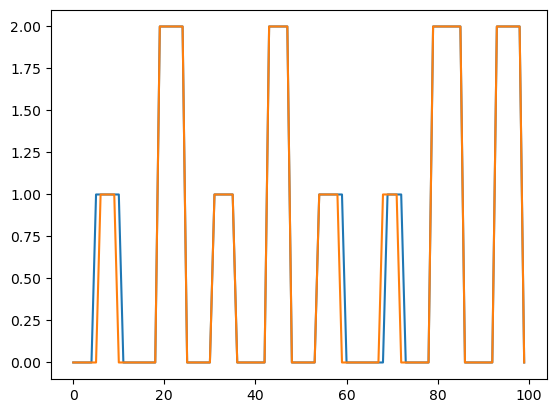

In [15]:
# Performance analysis

LT = pd.read_csv(label2_file)
labels = LT['Downsampled Carrier']

switched_labels=final_labels

from sklearn.metrics import confusion_matrix, balanced_accuracy_score

# Calculate the mean class accuracy
mean_class_accuracy2 = balanced_accuracy_score(labels, switched_labels)

# Create the confusion matrix
conf_matrix2 = confusion_matrix(labels, switched_labels, normalize='true')

print("Mean class accuracy:", mean_class_accuracy2)
print("Confusion Matrix:\n", conf_matrix2)

plt.plot(labels)
plt.plot(switched_labels)

### Result of the performance analysis

In [16]:
print("Mean class accuracy test 1:", mean_class_accuracy1)
print("Mean class accuracy test 2:", mean_class_accuracy2)
print ("Mean class accuracy:",(mean_class_accuracy1+mean_class_accuracy2)/2)

Mean class accuracy test 1: 0.8568459862577509
Mean class accuracy test 2: 0.9304473304473304
Mean class accuracy: 0.8936466583525406
